# Predicting Irrigation Need
- By : ABeer Al-Zebda | Machine Learning Engineer

# Dataset Description
The dataset for this competition (both train and test) was generated from a deep learning model trained on the Irrigation Prediction dataset. Feature distributions are close to, but not exactly the same, as the original. Feel free to use the original dataset as part of this competition, both to explore differences as well as to see whether incorporating the original in training improves model performance.
- competition link : https://www.kaggle.com/competitions/playground-series-s6e4/data

# Import Libraries

In [1]:
# Pandas is used to read and handle the dataset
import pandas as pd

# Matplotlib is used for plotting
import matplotlib.pyplot as plt
import seaborn as sns
# train_test_split is used to divide the data into training and testing sets
from sklearn.model_selection import train_test_split

# StandardScaler is used to standardize the features
from sklearn.preprocessing import StandardScaler, OneHotEncoder 

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline

# LogisticRegression is the ready-made classification model in scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor , RandomForestClassifier

# Accuracy score, confusion matrix, and classification report are used for evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Load and Inspect Data

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [5]:
df.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


# Clean Data

In [6]:
df.isna().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
for col in df:
    print(df[col].value_counts())

id
629983    1
629982    1
629981    1
629980    1
629979    1
         ..
4         1
3         1
2         1
1         1
0         1
Name: count, Length: 630000, dtype: int64
Soil_Type
Sandy    166509
Clay     158470
Loamy    156455
Silt     148566
Name: count, dtype: int64
Soil_pH
5.66    4986
5.53    4829
7.64    4746
7.97    4656
5.05    4586
        ... 
6.73     128
6.91     122
7.29     117
6.95      56
6.43      34
Name: count, Length: 341, dtype: int64
Soil_Moisture
52.38    1592
58.38    1250
43.23    1190
52.16    1181
49.74    1122
         ... 
44.65       1
45.54       1
23.55       1
20.59       1
14.65       1
Name: count, Length: 5223, dtype: int64
Organic_Carbon
0.58    9242
0.42    8808
0.84    7770
0.83    7460
0.66    7458
        ... 
0.91    1923
0.82    1557
0.87    1276
1.60     560
0.30      95
Name: count, Length: 131, dtype: int64
Electrical_Conductivity
2.69    5293
2.64    5267
2.37    4795
1.10    4501
0.97    4473
        ... 
2.62     124
3.50     119


# Explore Data

<Axes: xlabel='Irrigation_Need', ylabel='Soil_Moisture'>

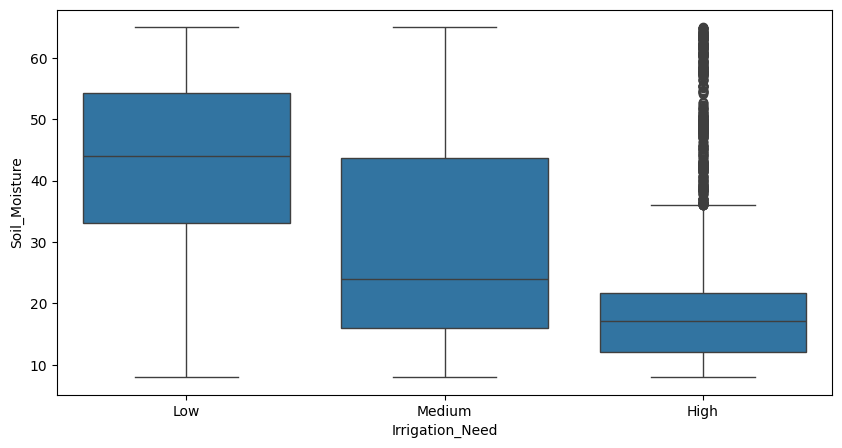

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x= 'Irrigation_Need' , y='Soil_Moisture')

<Axes: xlabel='Irrigation_Need', ylabel='Previous_Irrigation_mm'>

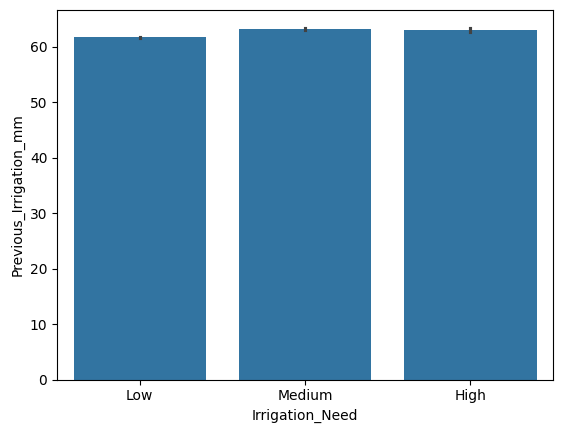

In [10]:
sns.barplot(data=df , x='Irrigation_Need' , y='Previous_Irrigation_mm')

# Preprocessing

In [11]:
# Create the input feature matrix
X = df.drop(["Irrigation_Need", "id"], axis=1)

# Create the target vector
y = df ["Irrigation_Need"]

In [12]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## One Hot Encoder for categorical Features

In [13]:
# Create the preprocessing pipeline for categorical data
cat_selector =  X_train.select_dtypes('object').columns
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_pipe = make_pipeline(ohe)

cat_tuple = ('categorical',cat_pipe, cat_selector)
cat_tuple

('categorical',
 Pipeline(steps=[('onehotencoder',
                  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
 Index(['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
        'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region'],
       dtype='object'))

## Scaling Numerical Features

In [14]:
# define numeric features and object features
num_cols = X_train.select_dtypes("number").columns

# feature scaling 
scaler = StandardScaler()  

# Instantiate the pipeline
num_pipe = make_pipeline(scaler)

# Make the tuple for ColumnTransformer
num_tuple = ('numeric',num_pipe,num_cols)
num_tuple

('numeric',
 Pipeline(steps=[('standardscaler', StandardScaler())]),
 Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
        'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
        'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm'],
       dtype='object'))

In [15]:
# Create the preprocessing ColumnTransformer
preprocessor = ColumnTransformer([cat_tuple, num_tuple],
verbose_feature_names_out=False)

preprocessor

ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region'],
      dtype='object')),
                                ('numeric',
                                 Pipeline(steps=[('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
       'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
       'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm'],
      dtype='object'))],
                  verbose_feature_names_out=False)

In [16]:
preprocessor.fit(X_train)
x_train_transformed=preprocessor.transform(X_train)
x_test_transformed=preprocessor.transform(X_test)

# Building The model

In [17]:
print("NaN in y_train:", y_train.isnull().sum())

NaN in y_train: 0


In [18]:
y_train.unique()

array(['Low', 'High', 'Medium'], dtype=object)

In [19]:
y_train_encoded = y_train.map({'Low': 0, 'Medium': 1, 'High': 2})
y_test_encoded  = y_test.map({'Low': 0, 'Medium': 1, 'High': 2})

In [20]:

# Create the RandomForestRegressor model
model = RandomForestClassifier(random_state=42)

# Train the model on the scaled training data
model.fit(x_train_transformed, y_train)


RandomForestClassifier(random_state=42)

In [21]:
y_train_pred = model.predict(x_train_transformed)
y_test_pred  = model.predict(x_test_transformed)


from sklearn.metrics import accuracy_score
print("Training accuracy:", round(accuracy_score(y_train, y_train_pred), 4))
print("Testing accuracy :", round(accuracy_score(y_test, y_test_pred), 4))


Training accuracy: 1.0
Testing accuracy : 0.985


# Evaluate The Model

In [22]:

print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))

              precision    recall  f1-score   support

        High       0.98      0.89      0.93      4249
         Low       0.99      1.00      0.99     73737
      Medium       0.98      0.98      0.98     48014

    accuracy                           0.99    126000
   macro avg       0.98      0.95      0.97    126000
weighted avg       0.99      0.99      0.98    126000

[[ 3772     0   477]
 [    0 73442   295]
 [   91  1022 46901]]


# predict on test Data

In [23]:
df2=pd.read_csv('test.csv')

In [26]:

new_x = preprocessor.transform(df2)

y_pred = model.predict(new_x)

results = pd.DataFrame({
    'Soil_Type':            df2['Soil_Type'].values,
    'Soil_pH':              df2['Soil_pH'].values.round(2),
    'Soil_Moisture':        df2['Soil_Moisture'].values.round(2),
    'Temperature_C':        df2['Temperature_C'].values.round(2),
    'Humidity':             df2['Humidity'].values.round(2),
    'Crop_Type':            df2['Crop_Type'].values,
    'Crop_Growth_Stage':    df2['Crop_Growth_Stage'].values,
    'Season':               df2['Season'].values,
    'Irrigation_Need':      ['Low ' if p == 'Low' else 'Medium ' if p == 'Medium' else 'High ' for p in y_pred]
    })
print(" Predicting Irrigation Need :")
print(results)

 Predicting Irrigation Need :
       Soil_Type  Soil_pH  Soil_Moisture  Temperature_C  Humidity Crop_Type  \
0           Silt     6.36          26.19          17.83     30.24     Maize   
1           Clay     5.87           9.88          21.18     78.07    Cotton   
2          Sandy     6.22          26.55          26.87     60.35     Wheat   
3           Clay     7.68          53.58          41.74     36.05     Maize   
4          Loamy     5.23          59.02          41.08     52.47    Cotton   
...          ...      ...            ...            ...       ...       ...   
269995     Sandy     5.63          51.90          33.27     72.09    Potato   
269996     Loamy     7.84          45.16          27.55     45.16     Wheat   
269997     Loamy     7.83          11.02          23.39     64.87     Maize   
269998      Silt     7.12          10.18          41.09     58.04      Rice   
269999      Clay     6.61          24.96          35.15     61.30     Maize   

       Crop_Growth_St

In [28]:
output_df = pd.DataFrame({
    'id': df2['id'].values,
    'Irrigation_Need': ['Low' if p == 'Low' else 'Medium ' if p == 'Medium' else 'High ' for p in y_pred]
})

# Save to new CSV file
output_df.to_csv('irrigation_predictions.csv', index=False)

print("Predictions saved to 'irrigation_predictions.csv'")
print(output_df.head())

Predictions saved to 'irrigation_predictions.csv'
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
